## Parts for figure 3 

In [4]:
# imports
import torch
import pickle
from collections import Counter
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
os.chdir('/home/grig0076/GitHubs/Phynteny_transformer_15012025/Phynteny_transformer/')
from src import predictor
from src import model_onehot
from importlib_resources import files
from torch.utils.data import DataLoader
import numpy as np
import random
import umap
import pacmap
import re
import textwrap
from upsetplot import UpSet, from_indicators
from matplotlib.colors import to_rgba
from scipy.ndimage import gaussian_filter1d

# stuff for making plots 
import torch
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc 

In [3]:
# read in categories 
phrog_integer = pickle.load(open('/home/grig0076/GitHubs/Phynteny_transformer_15012025/Phynteny_transformer/phynteny_utils/integer_category.pkl', 'rb'))
phrog_integer = dict(
            zip(
                [i - 1 for i in list(phrog_integer.keys())],
                [i for i in list(phrog_integer.values())],
            )
        )

In [3]:
# read in pharokka embeddings and categories 
prophage_embeddings = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/prophages/pharokka_checkv_filter/data.X.pkl', 'rb'))
prophage_categories = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/prophages/pharokka_checkv_filter/data.y.pkl', 'rb'))

# read in the phold predictions
phold_prophage_categories = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/prophages/pharokka_checkv_filter/phold_data.y.pkl', 'rb'))
phold_prophage_categories = {k: v for d in phold_prophage_categories for k, v in d.items()}  

/home/grig0076/miniconda3/envs/phynteny_transformer2/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.By

In [4]:
# get the phynteny annotations for these predictions 
phynteny_prophage_predictions = pd.DataFrame()

for i in range(1,7): # change this to the correct range
    #tab = pd.read_csv(f'/home/grig0076/scratch/Phynteny_transformer/prophages/phynteny/part_00{i}/phynteny.tsv', sep = '\t')
    #tab = pd.read_csv(f'/home/grig0076/scratch/Phynteny_transformer/prophages/phynteny_lambda_model/part_00{i}/phynteny.tsv', sep = '\t')
    tab = pd.read_csv(f'/home/grig0076/scratch/Phynteny_transformer/prophages/phynteny_per_model/part_00{i}/phynteny.tsv', sep = '\t')
    phynteny_prophage_predictions = pd.concat([phynteny_prophage_predictions,tab])
    
# filter out cases where the entire phage genome contains no known phrogs 
phage = list(set(phynteny_prophage_predictions['phage']))
exclude = [] # list the genomes that will get excluded 

for p in phage: 
    this_phage = phynteny_prophage_predictions[phynteny_prophage_predictions['phage'] == p]
    if len(this_phage[this_phage['phrog_category'] != 'unknown function']) == 0: 
        exclude.append(p) 
        
phynteny_prophage_predictions = phynteny_prophage_predictions[~phynteny_prophage_predictions['phage'].isin(exclude)] 
phynteny_prophage_predictions = phynteny_prophage_predictions[phynteny_prophage_predictions['phage'].isin(list(prophage_embeddings.keys()))]  # check that all of these are in the filtered set 

In [13]:
pharokka_annotation_counts = pd.DataFrame.from_dict(Counter(phynteny_prophage_predictions ['phrog_category'].to_list()), orient='index')

### Here make a plot that compares the amount of genes that get annotated using different confidence cutoff 

Also repeat this with the inphared dataset 

In [245]:
phages = set(phynteny_prophage_predictions['phage'])
num_known = []
num_genes = []
num_phynteny = []
confidence = 0.8

for p in phages: 
    this_phage = phynteny_prophage_predictions[phynteny_prophage_predictions['phage'] == p]
    num_known.append(len(this_phage[this_phage['phrog_category'] != 'unknown function']))
    num_phynteny.append(len(this_phage[this_phage['phynteny_confidence'] >= confidence]))
    num_genes.append(len(this_phage))
    
    

In [267]:
# plot the difference in the number known and the number annotated 
num_annotations_df = pd.DataFrame.from_dict({'phage': list(phages), 'num_known': num_known, 'num_phynteny': num_phynteny, 'num_genes': num_genes})
num_annotations_df['num_annotations'] = num_annotations_df['num_known'] + num_annotations_df['num_phynteny']

# add in the portion annotated
num_annotations_df['portion_known'] = num_annotations_df['num_known']*100/num_annotations_df['num_genes']
num_annotations_df['portion_annotated'] = num_annotations_df['num_annotations']*100/num_annotations_df['num_genes']

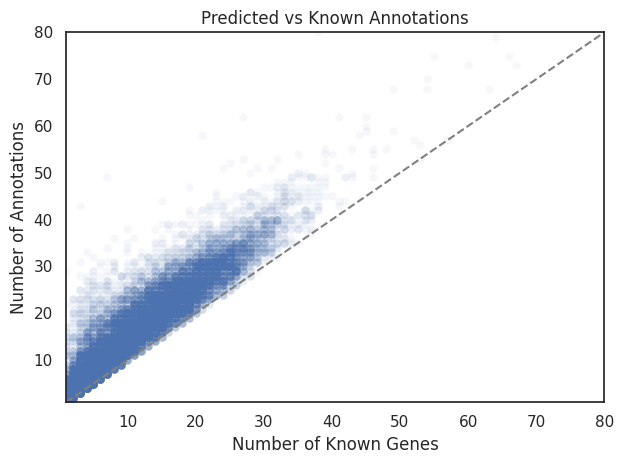

In [258]:
sns.set(style='white', font_scale=1.0)
sns.scatterplot(data=num_annotations_df, x = 'num_known', y ='num_annotations', linewidth=0, alpha=0.05)

lims = [
    min(num_annotations_df['num_known'].min(), num_annotations_df['num_annotations'].min()),
    max(num_annotations_df['num_known'].max(), num_annotations_df['num_annotations'].max())
]
plt.plot(lims, lims, linestyle='--', color='gray')

# Set limits to ensure square aspect if desired
plt.xlim(lims)
plt.ylim(lims)

# Optional labels
plt.xlabel("Number of Known Genes")
plt.ylabel("Number of Annotations")
plt.title("Predicted vs Known Annotations")

plt.tight_layout()
plt.show()

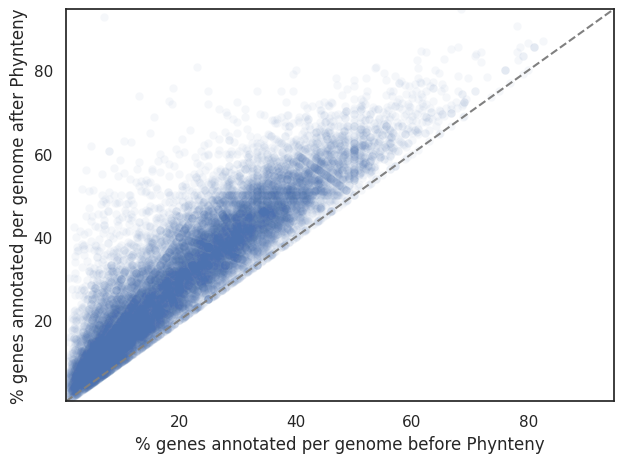

In [288]:
sns.scatterplot(data=num_annotations_df, x = 'portion_known', y ='portion_annotated', linewidth=0, alpha=0.05)

lims = [
    min(num_annotations_df['portion_known'].min(), num_annotations_df['portion_annotated'].min()),
    max(num_annotations_df['portion_known'].max(), num_annotations_df['portion_annotated'].max())
]
plt.plot(lims, lims, linestyle='--', color='gray')

# Set limits to ensure square aspect if desired
plt.xlim(lims)
plt.ylim(lims)

# Optional labels
plt.xlabel("% genes annotated per genome before Phynteny")
plt.ylabel("% genes annotated per genome after Phynteny")

plt.tight_layout()
plt.show()

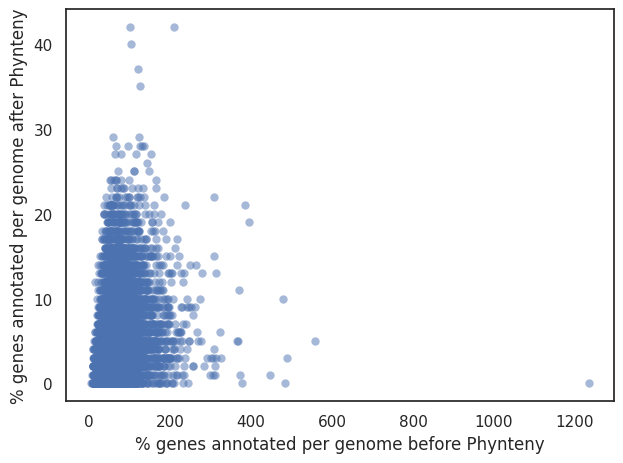

In [330]:
sns.scatterplot(data=num_annotations_df, x = 'num_genes', y ='num_phynteny', linewidth=0, alpha=0.5)


# Optional labels
plt.xlabel("% genes annotated per genome before Phynteny")
plt.ylabel("% genes annotated per genome after Phynteny")

plt.tight_layout()
plt.show()

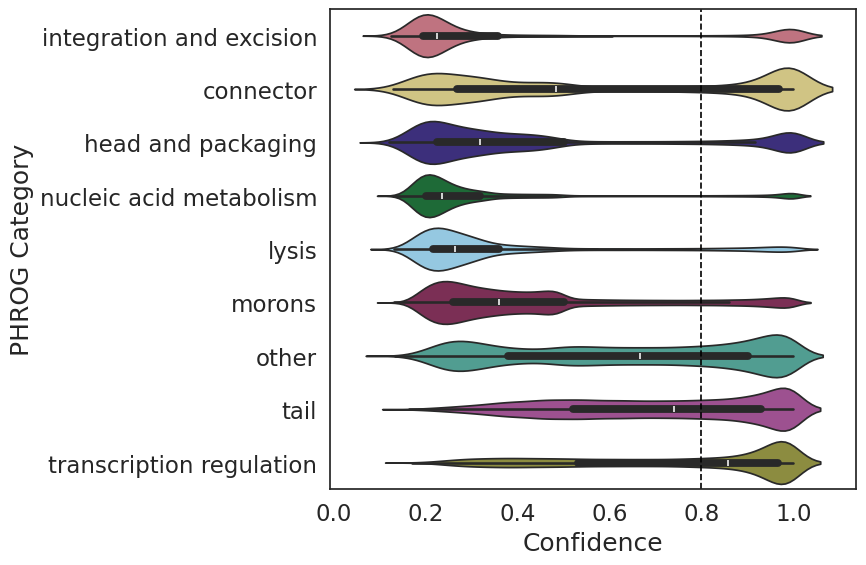

In [22]:
# Simplified category names
name_dict = {
    'integration and excision': 'integration and excision',
    'connector': 'connector',
    'head and packaging': 'head and packaging',
    'DNA, RNA and nucleotide metabolism': 'nucleic acid metabolism',
    'lysis': 'lysis',
    'moron, auxiliary metabolic gene and host takeover': 'morons',
    'other': 'other',
    'tail': 'tail',
    'transcription regulation': 'transcription regulation'
}

# Category order
base_order = [
    'integration and excision',
    'connector',
    'head and packaging',
    'nucleic acid metabolism',
    'lysis',
    'morons',
    'other',
    'tail',
    'transcription regulation'
]

# Custom color palette
colors1 = ['#CC6677', '#DDCC77', '#332288', '#117733', '#88CCEE',
           '#882255', '#44AA99', '#AA4499', '#999933']
palette = {label: color for label, color in zip(base_order, colors1)}

# set the fontscale 
sns.set(style='white' , font_scale=1.5)

# Prepare the DataFrame
df = phynteny_prophage_predictions.reset_index().copy()
df['phynteny_category_simple'] = df['phynteny_category'].map(name_dict)
df['phynteny_category_simple'] = pd.Categorical(df['phynteny_category_simple'], categories=base_order, ordered=True)

# --- Violin plot only ---
plt.figure(figsize=(9, 6))
sns.violinplot(
    data=df,
    y='phynteny_category_simple',
    x='phynteny_confidence',
    hue='phynteny_category_simple',
    palette=palette,
    order=base_order,
    legend=False
)

# Add threshold line at 0.8
plt.axvline(x=0.8, linestyle='--', color='black', linewidth=1.2)

# Labels and layout
plt.xlabel("Confidence")
plt.ylabel("PHROG Category")
#plt.title("Prediction Confidence by Category")
plt.tight_layout()
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/model_confidence_per_category.png')
plt.show()




### count the number of PHROGs that get annotated with Phynteny 
Count how many unknown PHROGs get predictions - could make a table or a small figure of this 

In [ ]:
# count the number of unknown phrogs that are in the prophage dataset 

In [6]:
phynteny_prophage_predictions_unknownfunction = phynteny_prophage_predictions[phynteny_prophage_predictions['phrog_category'] == 'unknown function']
phynteny_prophage_predictions_unknownfunction_withphrog = phynteny_prophage_predictions_unknownfunction[phynteny_prophage_predictions_unknownfunction['phrog_id'] != 'No_PHROG']

In [7]:
len(phynteny_prophage_predictions_unknownfunction_withphrog)

113755

In [73]:
# get the percentage of unknowns that have an PHROG annotation 
len(phynteny_prophage_predictions_unknownfunction_withphrog)*100/len(phynteny_prophage_predictions_unknownfunction)

# see how many unknown PHROGs these span 
len(list(set(phynteny_prophage_predictions_unknownfunction_withphrog['phrog_id']))) 

# get unknown PHROGs that get annotated with phynteny 
phynteny_prophage_predictions_phrogsannot = phynteny_prophage_predictions_unknownfunction_withphrog[phynteny_prophage_predictions_unknownfunction_withphrog['phynteny_confidence'] >= 0.8] 

# count the phrogs 
unknown_phrog_counts = pd.DataFrame.from_dict(Counter(phynteny_prophage_predictions_phrogsannot['phrog_id']), orient='index')
unknown_phrog_nonsingleton = unknown_phrog_counts[unknown_phrog_counts[0] != 1].index.to_list() 
print(len(unknown_phrog_nonsingleton)) # get the number of nonsingleton PHROGs annotated 

2168


/home/grig0076/miniconda3/envs/phynteny_transformer2/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/grig0076/miniconda3/envs/phynteny_transformer2/lib/python3.12/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the interm

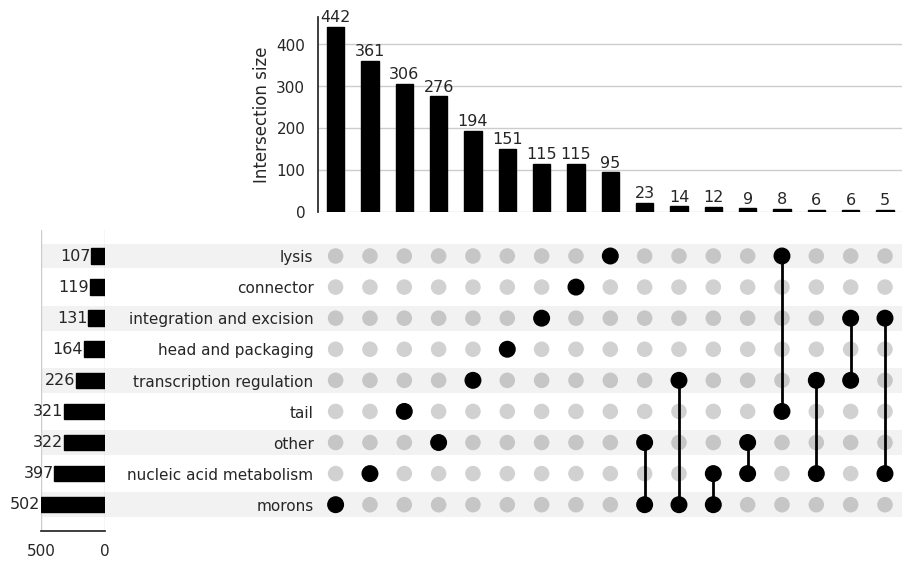

In [78]:
# build an upset plot 

sns.set(font_scale=1.0, style='white')
df = phynteny_prophage_predictions_phrogsannot[['phrog_id', 'phynteny_category']].copy()

# Rename categories
df['phynteny_category'] = df['phynteny_category'].replace({
    'DNA, RNA and nucleotide metabolism': 'nucleic acid metabolism',
    'moron, auxiliary metabolic gene and host takeover': 'morons'
})

# drop the singleton PHROGs 
df = df[df['phrog_id'].isin(unknown_phrog_nonsingleton)]

# Create one-hot (boolean) matrix
hits_per_phrog = pd.crosstab(df['phrog_id'], df['phynteny_category']).astype(bool)

# Convert to the UpSet input format
data = from_indicators(hits_per_phrog.columns.tolist(), hits_per_phrog)

# Adjust font size
plt.rcParams.update({'font.size': 11.5})

# Plot with minimum intersection size filter
up = UpSet(data, show_counts=True, sort_by='cardinality',min_subset_size=5)
up.plot()
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/unknownphrogs_upset.png')
plt.show()

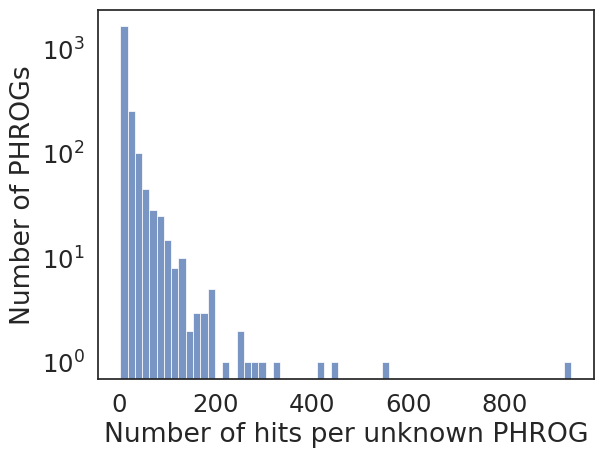

In [87]:
sns.set(font_scale=1.6, style='white')
sns.histplot(unknown_phrog_counts[unknown_phrog_counts[0] != 1][0].to_list(), binwidth=15, legend=False)
plt.yscale('log') 
plt.xlabel('Number of hits per unknown PHROG')
plt.ylabel('Number of PHROGs')
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/unknownphrogs_distcounts.png',  dpi=300, bbox_inches="tight")
plt.show()

## Make a plot comparing the number of genes annotated before and after - showing that well annotated phages become more well annotated 
Repeat this for the inphared phages

In [37]:
categories = list(set(phynteny_prophage_predictions[phynteny_prophage_predictions['phrog_category'] == 'unknown function']['phynteny_category']))

lysis
tail
head and packaging
DNA, RNA and nucleotide metabolism
transcription regulation
other
moron, auxiliary metabolic gene and host takeover
integration and excision
connector


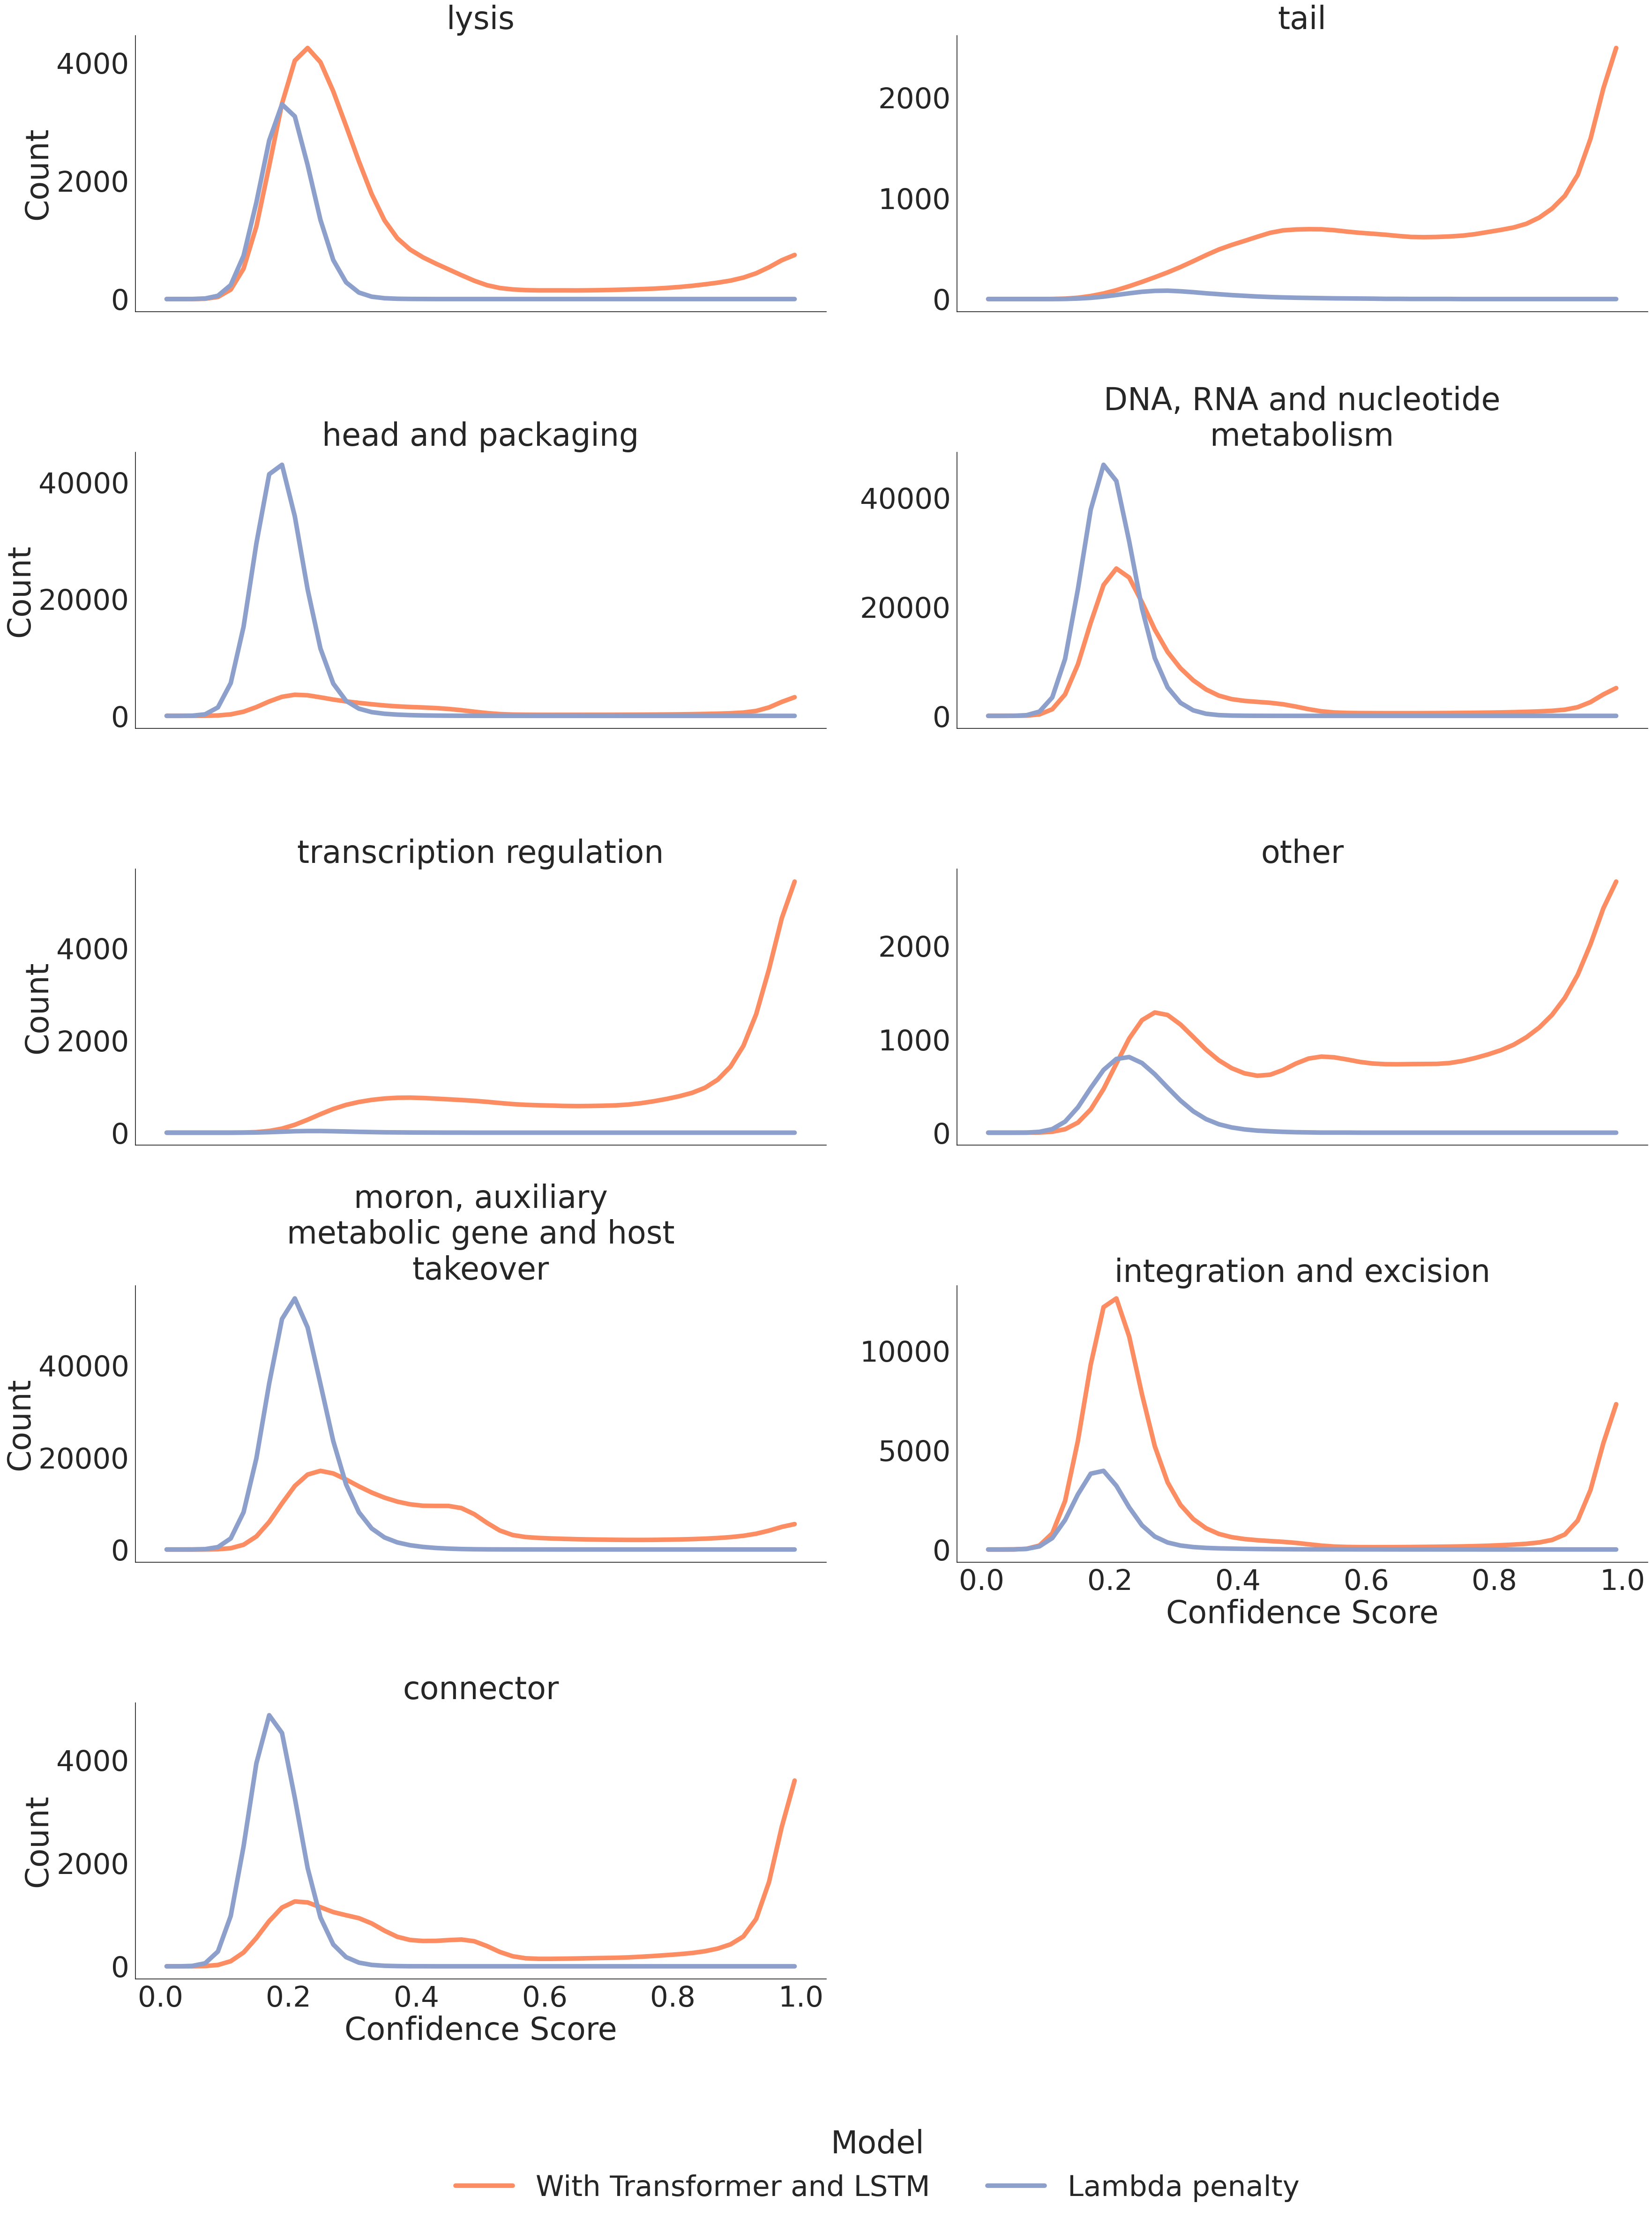

In [42]:
# Function to wrap long category names over two lines
def wrap_label(label, width=25):
    return "\n".join(textwrap.wrap(label, width=width))

# Define finer bins and compute bin centers
shared_bins = np.linspace(0, 1, 51)
bin_centers = 0.5 * (shared_bins[1:] + shared_bins[:-1])

# Prepare long-format dataframe for plotting
plot_data = []

for c in categories:
    # Subset each dataframe by category
    df_with = phynteny_prophage_predictions[phynteny_prophage_predictions['phynteny_category'] == c]
    df_without = phynteny_no_transformer_predictions[phynteny_no_transformer_predictions['phynteny_category'] == c]

    # Compute histogram counts
    counts_with, _ = np.histogram(df_with['phynteny_confidence'], bins=shared_bins)
    counts_without, _ = np.histogram(df_without['phynteny_confidence'], bins=shared_bins)

    # Apply Gaussian smoothing
    smooth_with = gaussian_filter1d(counts_with, sigma=1.5)
    smooth_without = gaussian_filter1d(counts_without, sigma=1.5)

    # Wrap category label
    wrapped_c = wrap_label(c)

    # Add to long-format list
    for bin_center, val in zip(bin_centers, smooth_with):
        plot_data.append({'Confidence': bin_center, 'Count': val, 'Model': 'With Transformer and LSTM', 'Category': wrapped_c})
    for bin_center, val in zip(bin_centers, smooth_without):
        plot_data.append({'Confidence': bin_center, 'Count': val, 'Model': 'Without Transformer and LSTM', 'Category': wrapped_c})

# Convert to DataFrame
plot_df = pd.DataFrame(plot_data)

# Set seaborn style to plain white
sns.set(style="white", font_scale=4)

# Create FacetGrid with independent y-axes
g = sns.FacetGrid(plot_df, col="Category", col_wrap=2, height=9, sharex=True, sharey=False)

# Map lineplot to grid
g.map_dataframe(sns.lineplot, x="Confidence", y="Count", hue="Model", palette=['#fc8d62', '#8da0cb'], linewidth=7)

# Remove gridlines and spines for clean look
for ax in g.axes.flat:
    ax.grid(False)
    sns.despine(ax=ax)

# Adjust legend and labels
g.add_legend(title="Model", loc='lower center', bbox_to_anchor=(0.53, -0.07), ncol=2, frameon=False)

# set title and axes labels
g.set_axis_labels("Confidence Score", "Count")
g.set_titles("{col_name}")
g.tight_layout()

# Save or show
plt.tight_layout()
plt.savefig("/home/grig0076/GitHubs/Phynteny_transformer/confidence_facetplot.png", dpi=300, bbox_inches='tight' )
plt.show()


## Visualise with ESM embeddings

In [8]:
# take a subset of keys to visualise 
#subset_keys = random.sample(list(prophage_categories.keys()), 1000)
subset_keys = list(set(phynteny_prophage_predictions['phage'])) 

# get embeddings and categories for this subset
plot_embeddings = np.vstack([np.array([j for j in x.detach().numpy()[:, 3:]]) for x in [prophage_embeddings.get(k) for k in subset_keys]])
plot_categories = np.hstack([x.detach().numpy() for x in [prophage_categories.get(k) for k in subset_keys]])
plot_categories_phold = np.hstack([x.detach().numpy() for x in [phold_prophage_categories.get(k) for k in subset_keys]])

In [9]:
# perform a PACMAP on these embeddings  
dimension_reducer = pacmap.PaCMAP(n_components=2, random_state=42, n_neighbors=20)
pacmap_embedding = dimension_reducer.fit_transform(plot_embeddings)

# Convert to DataFrame for easy plotting
pacmap_df = pd.DataFrame(pacmap_embedding)
pacmap_df['category'] = plot_categories
pacmap_df['label'] = [phrog_integer.get(i) for i in pacmap_df['category']]

In [85]:
#subset_phynteny = phynteny_subset_phold_labelsdictions[phynteny_prophage_predictions['phage'].isin(subset_keys)] # see why there is inconsistency here in the length of the dataframe
pc = 0.8 # set the confidence level

subset_phynteny_labels = []
subset_phold_labels = [] 
for s in subset_keys: 
    
    subset_phynteny = phynteny_prophage_predictions[phynteny_prophage_predictions['phage'] == s] 
    
    for i in range(len(subset_phynteny)):
        if subset_phynteny.iloc[i]['phrog_category'] != 'unknown function': 
                   subset_phynteny_labels.append(subset_phynteny.iloc[i]['phrog_category'])
        elif subset_phynteny.iloc[i]['phynteny_confidence'] > pc: 
                   subset_phynteny_labels.append(subset_phynteny.iloc[i]['phynteny_category'])
        else: 
                    subset_phynteny_labels.append('unknown function')
                
    phold_labels = [phrog_integer.get(int(i)) for i in phold_prophage_categories.get(s)]
    subset_phold_labels.extend(phold_labels)
            
pacmap_df['phynteny_labels'] = subset_phynteny_labels
pacmap_df['phold_labels'] = subset_phold_labels

In [148]:
pacmap_df[pacmap_df['phynteny_labels'] != 'unknown function']

,0,1,category,label,phynteny_labels,phynteny_labels_2,phold_labels,length,length max
497412,-1.491997,-6.351569,-1,unknown function,"moron, auxiliary metabolic gene and host takeover",unknown function,unknown function,29,29
781011,-1.538823,-6.814954,-1,unknown function,"moron, auxiliary metabolic gene and host takeover",unknown function,unknown function,29,29
205502,-1.324883,-6.839786,-1,unknown function,"moron, auxiliary metabolic gene and host takeover",unknown function,unknown function,29,29
493026,-19.614225,6.310465,-1,unknown function,"moron, auxiliary metabolic gene and host takeover",unknown function,unknown function,29,29
17239,-1.184458,-6.926085,-1,unknown function,"moron, auxiliary metabolic gene and host takeover",unknown function,unknown function,29,29
...,...,...,...,...,...,...,...,...,...
702082,2.342805,-0.390159,5,"moron, auxiliary metabolic gene and host takeover","moron, auxiliary metabolic gene and host takeover",unknown function,"moron, auxiliary metabolic gene and host takeover",4872,2000
889110,2.336068,-0.399500,5,"moron, auxiliary metabolic gene and host takeover","moron, auxiliary metabolic gene and host takeover",unknown function,"moron, auxiliary metabolic gene and host takeover",4883,2000
741081,2.317598,-0.404789,5,"moron, auxiliary metabolic gene and host takeover","moron, auxiliary metabolic gene and host takeover",unknown function,"moron, auxiliary metabolic gene and host takeover",4891,2000
221638,2.437502,-7.070848,5,"moron, auxiliary metabolic gene and host takeover","moron, auxiliary metabolic gene and host takeover",connector,"moron, auxiliary metabolic gene and host takeover",5180,2000


In [87]:
colors1 = [ '#CC6677','#DDCC77', '#332288',  '#117733', '#88CCEE',
                    '#882255', '#44AA99',  '#AA4499', '#999933']
#palette = sns.color_palette(colors1)

labels_order = {
    3: 'DNA, RNA and nucleotide metabolism',
    1: 'connector',
    2: 'head and packaging',
    0: 'integration and excision',
    4: 'lysis',
    5: 'moron, auxiliary metabolic gene and host takeover',
    6: 'other',
    7: 'tail',
    8: 'transcription regulation',
}

# Map labels to colors
palette = {label: color for label, color in zip(labels_order.values(), colors1)}

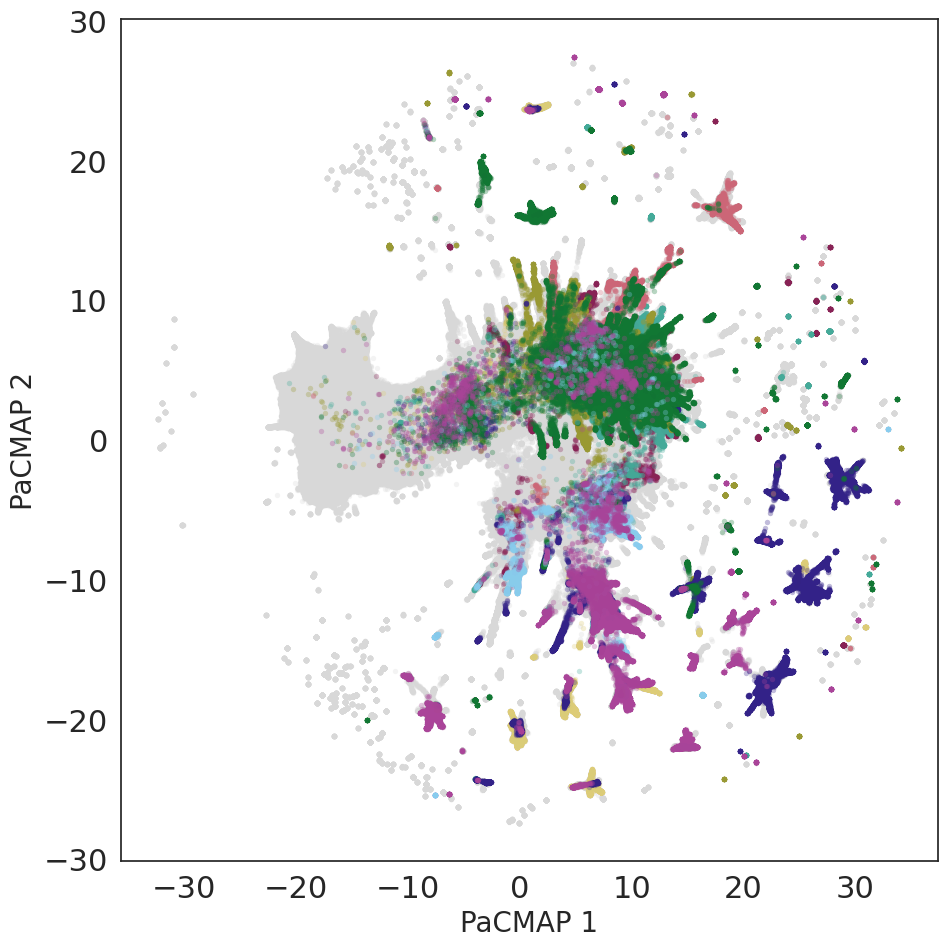

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define consistent color palette
colors1 = ['#CC6677', '#DDCC77', '#332288', '#117733', '#88CCEE',
           '#882255', '#44AA99', '#AA4499', '#999933']

labels_order = {
    3: 'DNA, RNA and nucleotide metabolism',
    1: 'connector',
    2: 'head and packaging',
    0: 'integration and excision',
    4: 'lysis',
    5: 'moron, auxiliary metabolic gene and host takeover',
    6: 'other',
    7: 'tail',
    8: 'transcription regulation',
}

# Create ordered list and color mapping
ordered_categories = [labels_order[i] for i in sorted(labels_order)]
palette = {label: color for label, color in zip(ordered_categories, colors1)}

# Ensure plotting order puts 'moron...' and 'other' first
low_priority = ['moron, auxiliary metabolic gene and host takeover', 'other', 'transcription regulation']
high_priority = [cat for cat in ordered_categories if cat not in low_priority]
plot_order = low_priority + high_priority

# Plot
sns.set(font_scale=2.0, style='white')
plt.figure(figsize=(10, 10))

# Plot unknown function (in light grey)
sns.scatterplot(
    data=pacmap_df[pacmap_df['label'] == 'unknown function'],
    x=0, y=1,
    color='#d8d8d8',
    linewidth=0,
    alpha=0.3,
    s=15
)

# Plot low-priority categories first
for category in plot_order:
    df_subset = pacmap_df[
        (pacmap_df['label'] != 'unknown function') &
        (pacmap_df['phynteny_labels'] == category)
    ]
    sns.scatterplot(
        data=df_subset,
        x=0, y=1,
        label=category,
        color=palette[category],
        linewidth=0,
        alpha=0.3,
        s=15
    )

# Axis labels and hide legend
plt.xlabel("PaCMAP 1", fontsize=20)
plt.ylabel("PaCMAP 2", fontsize=20)
plt.legend([], [], frameon=False)  # hide legend
plt.tight_layout()
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/pacmap_before_phynteny.png')
plt.show()


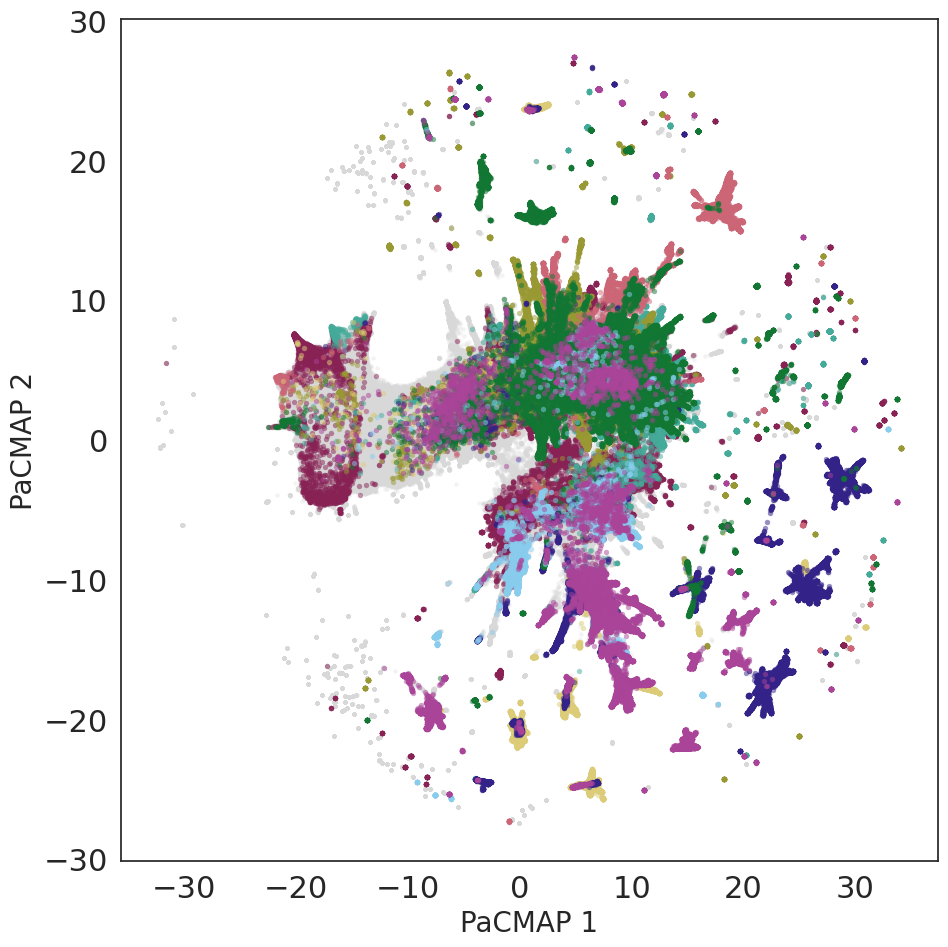

In [64]:
sns.set(font_scale=2.0, style='white')
plt.figure(figsize=(10, 10))

# Plot unknown function (light grey)
sns.scatterplot(
    data=pacmap_df[pacmap_df['phynteny_labels'] == 'unknown function'],
    x=0, y=1,
    color='#d8d8d8',
    linewidth=0,
    alpha=0.3,
    s=10
)

# Define plotting order with morons and other at the bottom
low_priority = ['moron, auxiliary metabolic gene and host takeover', 'other', 'transcription regulation']
high_priority = [cat for cat in palette.keys() if cat not in low_priority]
plot_order = low_priority + high_priority

# Plot known function categories in desired order
for category in plot_order:
    df_subset = pacmap_df[pacmap_df['phynteny_labels'] == category]
    sns.scatterplot(
        data=df_subset,
        x=0, y=1,
        label=category,
        color=palette[category],
        linewidth=0,
        alpha=0.5,
        s=15
    )

# Axis labels
plt.xlabel("PaCMAP 1", fontsize=20)
plt.ylabel("PaCMAP 2", fontsize=20)

# Hide legend
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/pacmap_after_phynteny.png')
plt.show()


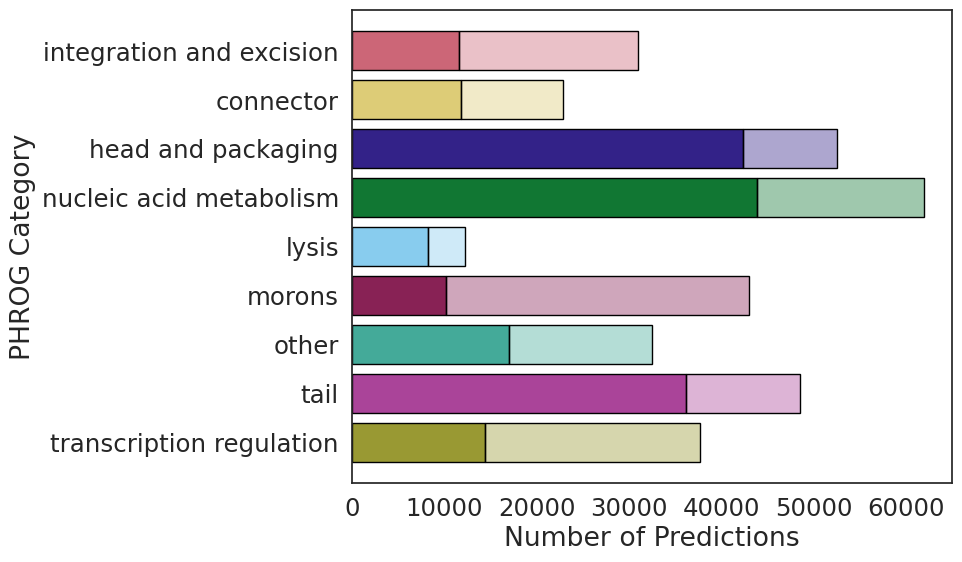

In [66]:
#set up seaborn 
sns.set(style='white', font_scale=1.6)

# Simplified category names for plotting
name_dict = {
    'integration and excision': 'integration and excision',
    'connector': 'connector',
    'head and packaging': 'head and packaging',
    'DNA, RNA and nucleotide metabolism': 'nucleic acid metabolism',
    'lysis': 'lysis',
    'moron, auxiliary metabolic gene and host takeover': 'morons',
    'other': 'other',
    'tail': 'tail',
    'transcription regulation': 'transcription regulation'
}

# Desired plot order (matches violinplot)
base_order = [
    'integration and excision',
    'connector',
    'head and packaging',
    'nucleic acid metabolism',
    'lysis',
    'morons',
    'other',
    'tail',
    'transcription regulation'
]

# Custom color palette matching order
colors1 = ['#CC6677', '#DDCC77', '#332288', '#117733', '#88CCEE',
           '#882255', '#44AA99', '#AA4499', '#999933']
palette = {label: color for label, color in zip(base_order, colors1)}

# Apply name mapping to input data
phynteny_labels_mapped = pacmap_df['phynteny_labels'].map(name_dict)
label_labels_mapped = pacmap_df['label'].map(name_dict)

# Count phynteny predictions and fill missing categories
phynteny_counts = phynteny_labels_mapped.value_counts().reindex(base_order, fill_value=0).reset_index()
phynteny_counts.columns = ['category', 'count']

# Count original predictions and fill missing categories
label_counts = label_labels_mapped.value_counts().reindex(base_order, fill_value=0).reset_index()
label_counts.columns = ['category', 'count']

# Merge and compute improvement
merged = pd.merge(phynteny_counts, label_counts, on='category', suffixes=('_phynteny', '_original'))
merged['improvement'] = merged['count_phynteny'] - merged['count_original']
merged = merged.set_index('category').loc[base_order].reset_index()

# Set up plot
fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(merged))

# Plot original counts (base layer)
for i, row in merged.iterrows():
    base_color = palette[row['category']]
    ax.barh(
        y=i,
        width=row['count_original'],
        color=base_color,
        edgecolor='black',
        linewidth=1
    )

# Plot Phynteny improvements (stacked)
for i, row in merged.iterrows():
    base_color = palette[row['category']]
    light_color = to_rgba(base_color, alpha=0.4)
    ax.barh(
        y=i,
        width=row['improvement'],
        left=row['count_original'],
        color=light_color,
        edgecolor='black',
        linewidth=1
    )

# Final plot settings
ax.set_xlabel("Number of Predictions")
ax.set_ylabel("PHROG Category")
ax.set_yticks(y)
ax.set_yticklabels(merged['category'])
ax.invert_yaxis()  # Top-to-bottom order

plt.tight_layout()
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/category_improvement.png')
plt.show()


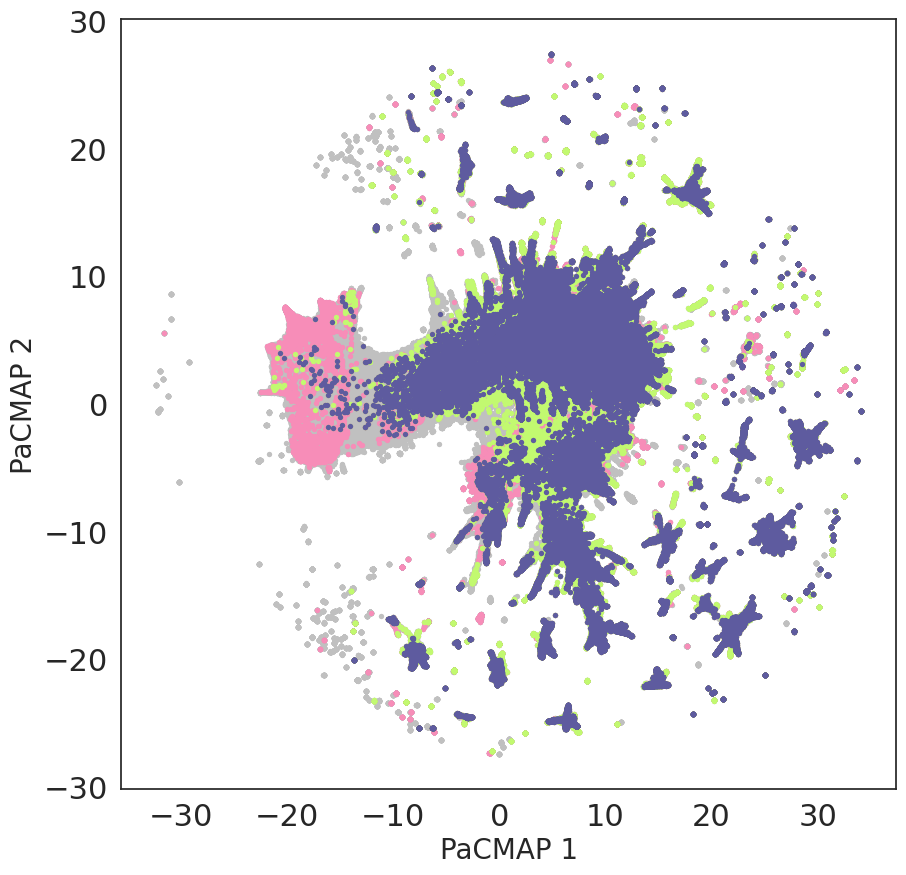

In [111]:
# Make figure square and increase font sizes
sns.set(font_scale=2.0, style='white')
plt.figure(figsize=(10,10))  # square: width = height

# Scatter plots
sns.scatterplot(data=pacmap_df, x=0, y=1, c='#c0c0c0', linewidth=0, s=15)
sns.scatterplot(data=pacmap_df[pacmap_df['phynteny_labels'] != 'unknown function'], x=0, y=1, c='#f78db8', linewidth=0, s=15) 
sns.scatterplot(data=pacmap_df[pacmap_df['phold_labels'] != 'unknown function'], x=0, y=1, c='#c2f970', linewidth=0, s=15) 
sns.scatterplot(data=pacmap_df[pacmap_df['label'] != 'unknown function'], x=0, y=1, c='#5e5b9f', linewidth=0, s=15) # all annotations as the background 

# Optional: Add axis labels and title for clarity
plt.xlabel("PaCMAP 1",  fontsize=20)
plt.ylabel("PaCMAP 2",  fontsize=20)

#save the figure 
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/phynteny_phold_pharokka_pacmap.png')
# Show plot
plt.show()

## Show sequence length on the plot

In [114]:
# read in the sequence lengths for these 
import pandas as pd

# Read the file
with open("/home/grig0076/scratch/Phynteny_transformer/prophages/pharokka_checkv_filter/fasta/mmseqs_cluster_minseqid0.9_c0.9_minseqid0.6_c0.75_PhageScope_derep.checkv_filter.phanotate.lengths.txt", "r") as f:
    lines = f.read().splitlines()

# Process the alternating lines into a dictionary
data = {"Header": lines[0::2], "Length": list(map(int, lines[1::2]))}

# Create DataFrame
df = pd.DataFrame(data)
df['Header'] = [h[1:] for h in df['Header']]



In [115]:
data = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/prophages/pharokka_checkv_filter/mmseqs_cluster_minseqid0.9_c0.9_minseqid0.6_c0.75_PhageScope_derep.checkv_filter.part_006.generate.g2.gpu/data.data.pkl', 'rb'))

In [116]:
all_length_dict = dict() 

for i in range(1,7): 
    
    data = pickle.load(open('/home/grig0076/scratch/Phynteny_transformer/prophages/pharokka_checkv_filter/mmseqs_cluster_minseqid0.9_c0.9_minseqid0.6_c0.75_PhageScope_derep.checkv_filter.part_00' + str(i) + '.generate.g2.gpu/data.data.pkl', 'rb'))
    keys = list(data.keys())

    ld = dict() 

    for k in keys: 
        lengths = [len(j.seq) for j in data.get(k).get('sequence')] 
        ld[k] = lengths 
        
    all_length_dict = all_length_dict | ld
    

In [117]:
subset_lengths = [all_length_dict.get(s) for s in subset_keys]
subset_lengths = [item for sublist in subset_lengths for item in sublist]
pacmap_df['length'] = subset_lengths 
pacmap_df['length max'] = [i if i <= 2000 else 2000 for i in pacmap_df['length'] ]
pacmap_df = pacmap_df.sort_values('length')

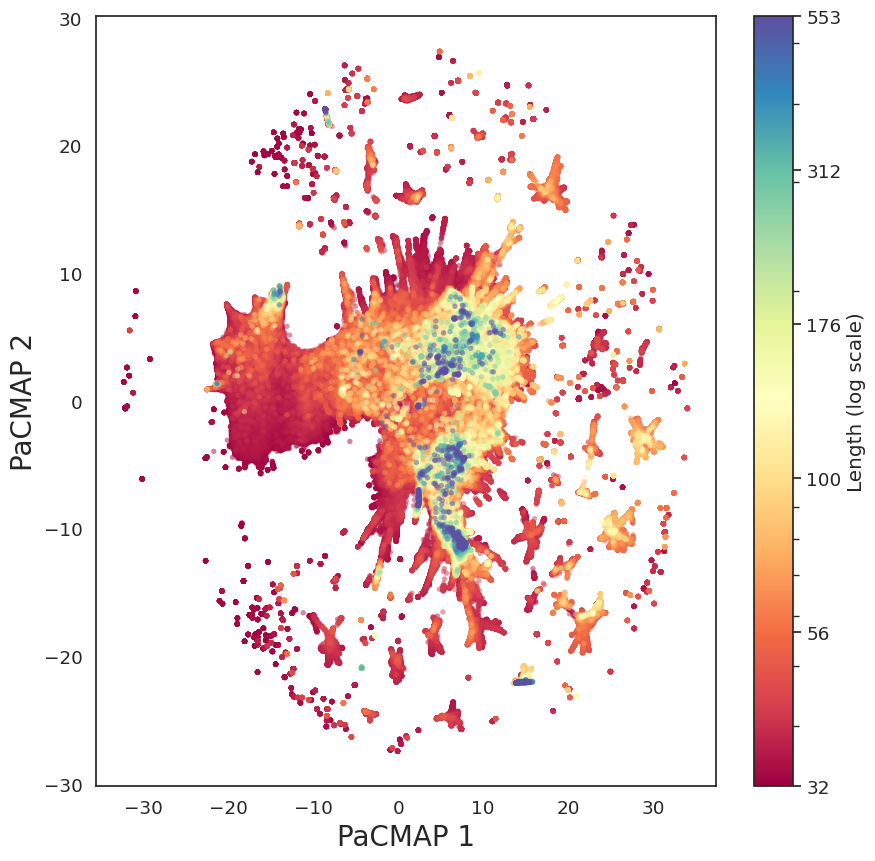

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.ticker import LogFormatter

plt.figure(figsize=(10, 10))
sns.set(font_scale=1.2, style='white')
# Sort by 'length max' so smaller values are plotted first
pacmap_df_sorted = pacmap_df.sort_values(by='length max', ascending=True)

# Define log-normalization with adjusted vmin and vmax
vmin = np.percentile(pacmap_df['length max'], 5)
vmax = np.percentile(pacmap_df['length max'], 95)
log_norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

# Create the scatter plot
scatter = sns.scatterplot(
    data=pacmap_df_sorted,
    x=0,
    y=1,
    hue='length max',
    palette='Spectral',
    linewidth=0,
    alpha=0.5,
    s=15
)

# Create scalar mappable for colorbar
sm = plt.cm.ScalarMappable(cmap='Spectral', norm=log_norm)
sm.set_array([])

# Get the current figure and axis
fig = plt.gcf()
ax = plt.gca()
ax.get_legend().remove()

# Add colorbar
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Length (log scale)')

# Manually define ticks (e.g., 3000 to 10000)
tick_values = np.geomspace(vmin, vmax, num=6)  # 6 evenly spaced ticks in log scale
cbar.set_ticks(tick_values)
cbar.set_ticklabels([f"{int(t):,}" for t in tick_values])

# Axis labels
plt.xlabel("PaCMAP 1", fontsize=20)
plt.ylabel("PaCMAP 2", fontsize=20)

# Save the figure
plt.savefig('/home/grig0076/GitHubs/Phynteny_transformer/sequence_length_pacmap.png')
plt.show()
